In [ ]:

# ---------- helpers ----------
def l1_turnover_pct(w_from, w_to):
    """One-way turnover (% of portfolio) to go from w_from → w_to."""
    return 0.5 * float(np.abs(w_to - w_from).sum()) * 100.0

def cosine_similarity(a, b):
    a = np.asarray(a); b = np.asarray(b)
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return float(np.dot(a, b) / (na * nb))

def realized_te_annual(w, w_b, Sigma):
    """Annualized TE in decimal (e.g., 0.02 == 2%)."""
    diff = (w - w_b)
    te_m = float(diff.T @ Sigma @ diff)
    te_a = np.sqrt(te_m) * np.sqrt(12.0)
    return te_a

def carbon_reduction_pct(w, w_b, c_vec):
    """% reduction relative to benchmark carbon; returns in percent units."""
    cb = float(np.dot(w_b, c_vec))
    co = float(np.dot(w,   c_vec))
    if cb == 0:
        return np.nan
    return (cb - co) / cb * 100.0

def nanpercentile(x, q):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.percentile(x, q)) if x.size else np.nan

def sensitivity_kpis_from_trials(
    w_trials,             # (n_trials, N) weights from perturbations (optimized each trial)
    te_trials_annual,     # (n_trials,) TE in decimal for each trial (annualized)
    R_clean,              # baseline returns (DataFrame without Date)
    w_bench,              # benchmark weights (N,)
    c_vec,                # carbon intensity per name (N,)
    Sigma_fn,             # function R_clean -> Sigma
    te_cap=0.02,          # baseline TE cap (annual)
    w_opt0=None           # baseline optimized weights; if None, will solve
):
    """
    Returns a dict with the KPIs + the raw per-trial series (for plots).
    """
    # Baseline (with clean Sigma)
    w_opt0, te0, Rstar0, Sigma0 = baseline_diagnostics(R_clean, w_bench, c_vec, Sigma_fn, te_cap, w_opt0)

    # Per-trial measures vs baseline optimized portfolio
    turnovers = []
    cosines   = []
    carbon_losses_pp = []   # baseline reduction minus trial reduction (pp)
    te_drifts_bps    = []   # |TE_trial - TE_baseline| in bps

    for w_t, te_t in zip(w_trials, te_trials_annual):
        if w_t is None or not np.all(np.isfinite(w_t)) or (te_t is None) or not np.isfinite(te_t):
            turnovers.append(np.nan); cosines.append(np.nan)
            carbon_losses_pp.append(np.nan); te_drifts_bps.append(np.nan)
            continue

        # Turnover and Cosine vs baseline optimized
        turnovers.append(l1_turnover_pct(w_opt0, w_t))
        cosines.append(cosine_similarity(w_opt0, w_t))

        # Carbon reduction loss (pp): max(0, baseline_reduction - trial_reduction)
        Rstar_t = carbon_reduction_pct(w_t, w_bench, c_vec)   # in %
        carbon_losses_pp.append(max(0.0, Rstar0 - Rstar_t))

        # TE drift (bps) relative to baseline TE
        te_drifts_bps.append(abs(te_t - te0) * 10000.0)

    # Aggregate KPIs
    kpis = {
        "Median_Turnover_pct":        nanpercentile(turnovers, 50),
        "Median_Cosine":              nanpercentile(cosines, 50),
        "P95_CarbonLoss_pp":          nanpercentile(carbon_losses_pp, 95),
        "P95_TE_Drift_bps":           nanpercentile(te_drifts_bps, 95),
        # keep handy for plots/debug
        "series": {
            "turnover_pct": np.array(turnovers, dtype=float),
            "cosine":       np.array(cosines, dtype=float),
            "carbon_loss_pp": np.array(carbon_losses_pp, dtype=float),
            "te_drift_bps":   np.array(te_drifts_bps, dtype=float),
            "baseline": {
                "w_opt0": w_opt0,
                "te0_annual": te0,
                "Rstar0_pct": Rstar0
            }
        }
    }
    return kpis

# ---------- baseline (can reuse your precomputed dict) ----------
def baseline_diagnostics(R_clean, w_bench, c_vec, Sigma_fn, te_cap=0.02, w_opt=None):
    """
    Returns (w_opt0, te0_annual, Rstar0, Sigma0)
    - If w_opt is None, solves the baseline optimization; otherwise uses provided w_opt.
    """
    # Sigma at baseline (on clean returns)
    Sigma0 = Sigma_fn(R_clean)

    if w_opt is None:
        # Solve baseline optim (same as your optimize_sector but minimal)
        N = len(w_bench)
        w = cp.Variable(N)
        te_cap_var_monthly = (te_cap / np.sqrt(12))**2
        tracking_error = cp.quad_form(w - w_bench, cp.psd_wrap(Sigma0))
        obj = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        cons = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(obj, cons)
        prob.solve(solver=cp.ECOS, verbose=False)
        if prob.status not in ("optimal","optimal_inaccurate") or w.value is None:
            raise RuntimeError(f"Baseline optimization failed: {prob.status}")
        w_opt0 = w.value
    else:
        w_opt0 = np.asarray(w_opt, dtype=float)

    te0 = realized_te_annual(w_opt0, w_bench, Sigma0)              # decimal, e.g. 0.02
    Rstar0 = carbon_reduction_pct(w_opt0, w_bench, c_vec)          # percent
    return w_opt0, te0, Rstar0, Sigma0
# === UTILITIES ===

def sigma_raw_fn(R_clean):
    return R_clean.cov()

def sigma_reg_fn(R_clean):
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    lambda_I = 1e-5
    return Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])

def simulate_parametric_noise(mu, Sigma, T, n_trials):
    return [np.random.multivariate_normal(mu, Sigma, T) for _ in range(n_trials)]

def bootstrap_returns(R_clean_np, n_trials):
    T = R_clean_np.shape[0]
    return [R_clean_np[np.random.choice(T, T, replace=True)] for _ in range(n_trials)]

def compute_perturbed_weights_from_samples(R_samples, w_bench, c_vec, Sigma_fn, te_cap=0.03):
    weights, tracking_errors = [], []
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    N = len(w_bench)

    for R_perturbed in R_samples:
        Sigma = Sigma_fn(pd.DataFrame(R_perturbed))
        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_bench, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            diff = w.value - w_bench
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)

def compute_perturbed_weights(
    R_clean,
    w_bench,
    c_vec,
    Sigma_fn,
    te_cap=0.03,
    n_trials=100,
    noise_std=0.01,
    noise_type="multiplicative"  # or "additive"
):
    N = R_clean.shape[1]
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    weights = []
    tracking_errors = []

    for seed in range(n_trials):
        np.random.seed(seed)
        noise = np.random.normal(0, noise_std, R_clean.shape)

        if noise_type == "multiplicative":
            R_perturbed = R_clean + R_clean.multiply(noise)
        elif noise_type == "additive":
            R_perturbed = R_clean + noise
        else:
            raise ValueError("noise_type must be 'multiplicative' or 'additive'")

        Sigma = Sigma_fn(R_perturbed)

        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_bench, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            diff = w.value - w_bench
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)


def compute_hhi(weights):
    return np.sum(np.square(weights))

def check_total_variability(R_clean, sector_name):
    sdev = R_clean.std(axis=0)
    annualised_sdev = sdev * (12**0.5)
    return annualised_sdev

# --- parameters ---
periods = [ "1221", "0322", "0622", "0922" ] #, "1222"] 
n_trials = 200

# --- containers ---
all_sensitivity = []

for period_tag in periods:
    print(f"\n🚀 Running sensitivity analysis for {period_tag} …")

    # define file paths
    data_file = f"data/datasets/benchmark_weights_carbon_intensity_{period_tag}.xlsx"
    returns_file = f"Data/log_returns/sector_log_returns_comp_{period_tag}_new.xlsx"
    optim_file = f"results/optimal_portfolios/optimal_portfolios_all_te_{period_tag}.pkl"
    out_dir = f"results/sensitivity"
    out_pickle = f"{out_dir}/sensitivity_kpis_{period_tag}.pkl"
    out_excel = f"{out_dir}/sensitivity_kpis_{period_tag}.xlsx"

    # -------------------------------
    # Load optimization frontier
    # -------------------------------
    with open(optim_file, "rb") as f:
        optimal_portfolios_all_te = pickle.load(f)

    optimal_portfolios_shrink_2_TE = extract_optimal_portfolios_at_target_te(
        optimal_portfolios_all_te, target_te_bps=200
    )

    os.makedirs(out_dir, exist_ok=True)

    # -------------------------------
    # Check cache
    # -------------------------------
    if os.path.exists(out_pickle) and os.path.exists(out_excel):
        print(f"✅ Using cached results for {period_tag}.")
        with open(out_pickle, "rb") as f:
            sensitivity_results = pickle.load(f)
        tmp = pd.read_excel(out_excel)
        tmp["Period"] = period_tag
        all_sensitivity.append(tmp)
        continue  # skip recomputation

    # -------------------------------
    # Run new computation
    # -------------------------------
    print(f"⚙️ Computing fresh sensitivity KPIs for {period_tag}…")

    data = pd.read_excel(data_file)
    sensitivity_results = {}

    for sector_name in data["GICS Sector"].unique():
        print(f"[{sector_name}] computing sensitivity KPIs…")

        # Load returns for this sector
        R = pd.read_excel(returns_file, sheet_name=sector_name)
        R_clean = R.drop(columns=["Date"]).dropna()

        # Benchmark weights + carbon intensity
        sector = data[data["GICS Sector"] == sector_name]
        w_bench = sector["weight_in_sector"].values
        c_vec = sector["Carbon Intensity"].values

        # Baseline optimized weights (already precomputed)
        w_opt0 = optimal_portfolios_shrink_2_TE[sector_name]["w_opt"]

        # === Perturbations ===
        w_trials, te_trials = compute_perturbed_weights(
            R_clean,
            w_bench,
            c_vec,
            sigma_reg_fn,
            te_cap=0.02,  # annual TE cap
            n_trials=n_trials,
            noise_std=0.2,
            noise_type="multiplicative",
        )

        # === Compute KPIs ===
        kpis = sensitivity_kpis_from_trials(
            w_trials=w_trials,
            te_trials_annual=te_trials,
            R_clean=R_clean,
            w_bench=w_bench,
            c_vec=c_vec,
            Sigma_fn=sigma_reg_fn,
            te_cap=0.02,
            w_opt0=w_opt0,
        )

        sensitivity_results[sector_name] = {
            "Median_Turnover_pct": kpis["Median_Turnover_pct"],
            "Median_Cosine": kpis["Median_Cosine"],
            "P95_CarbonLoss_pp": kpis["P95_CarbonLoss_pp"],
            "P95_TE_Drift_bps": kpis["P95_TE_Drift_bps"],
        }

    # -------------------------------
    # Save new results
    # -------------------------------
    tmp = pd.DataFrame(sensitivity_results).T.reset_index()
    tmp.rename(columns={"index": "Sector"}, inplace=True)
    tmp["Period"] = period_tag

    with open(out_pickle, "wb") as f:
        pickle.dump(sensitivity_results, f)
    tmp.to_excel(out_excel, index=False)

    print(f"✅ Saved results for {period_tag} to {out_pickle}")

    all_sensitivity.append(tmp)

# -------------------------------
# Combine all periods
# -------------------------------
panel_df = pd.concat(all_sensitivity, ignore_index=True)
panel_df.to_excel("results/sensitivity_kpis_panel.xlsx", index=False)
print("\n✅ All periods processed and saved to results/sensitivity_kpis_panel.xlsx")

# Define all periods
periods = [ "1221", "0322", "0622", "0922" ] #, "1222"]

all_vols = []

for p in periods:
    print(f"📊 Processing volatility for period {p} ...")
    
    # --- Load data ---
    optim_path = f"results/optimal_portfolios/optimal_portfolios_all_te_{p}.pkl"
    returns_path = f"data/log_returns/sector_log_returns_comp_{p}.xlsx"
    
    if not os.path.exists(optim_path) or not os.path.exists(returns_path):
        print(f"⚠️ Missing data for {p}, skipping.")
        continue
    
    with open(optim_path, "rb") as file:
        optimal_data = pickle.load(file)
    
    # --- Compute volatility per sector ---
    for sector_name in optimal_data.keys():
        try:
            # Load sector returns
            R = pd.read_excel(returns_path, sheet_name=sector_name)
            R_clean = R.drop(columns=['Date']).dropna()
            
            # Benchmark weights (last period or stored)
            w_b = optimal_data[sector_name]["w_bench"]
            
            # Compute benchmark portfolio returns
            r_bench = (R_clean * w_b).sum(axis=1)
            
            # Annualized volatility (using monthly returns)
            vol_annual = np.std(r_bench) * np.sqrt(12)
            
            all_vols.append({
                "Sector": sector_name,
                "Period": p,
                "Benchmark_Volatility": vol_annual
            })
        except Exception as e:
            print(f"⚠️ Error for {sector_name} ({p}): {e}")

# --- Combine results ---
vol_df = pd.DataFrame(all_vols)
vol_df = vol_df.sort_values(["Sector", "Period"])
vol_df.to_excel("results/benchmark_volatility_by_period.xlsx", index=False)

print("✅ Saved benchmark volatility by sector and period.")

# --- helper ---
def minmax_norm(x):
    x = np.asarray(x, float)
    if np.nanmax(x) == np.nanmin(x):
        return np.zeros_like(x)
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

# --- load data ---
sens_panel = pd.read_excel("results/sensitivity_kpis_panel.xlsx")   # must include Sector, Period
sens_panel["Period"] = sens_panel["Period"].astype(str).str.zfill(4)

df = sens_panel.copy()

# --- compute composition sensitivity (no volatility adjustment) ---
df["Turnover_norm"] = minmax_norm(df["Median_Turnover_pct"])
df["Cosine_norm"]   = minmax_norm(1 - df["Median_Cosine"])

df["Composition_Sensitivity"] = 0.5 * (df["Turnover_norm"] + df["Cosine_norm"])

# --- outcome sensitivity ---
df["Outcome_Sensitivity"] = 0.5 * (
    minmax_norm(df["P95_CarbonLoss_pp"]) +
    minmax_norm(df["P95_TE_Drift_bps"])
)

# --- overall sensitivity score ---
df["Sensitivity_Score"] = 0.5 * (
    minmax_norm(df["Composition_Sensitivity"]) +
    minmax_norm(df["Outcome_Sensitivity"])
)

# --- save and plot ---
df.to_excel("results/sensitivity_scores_by_period.xlsx", index=False)
print("✅ Saved sensitivity scores to results/sensitivity_scores_by_period.xlsx")

plt.figure(figsize=(10,6))
for sector, grp in df.groupby("Sector"):
    plt.plot(grp["Period"], grp["Sensitivity_Score"], marker="o", label=sector)

plt.title("Evolution of TE Sensitivity Score per Sector")
plt.ylabel("Sensitivity Score (0–1, higher = more stable)")
plt.xlabel("Period")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()
sensitivity_score_df = df[['Sector', 'Period', 'Sensitivity_Score']]
 


🚀 Running sensitivity analysis for 1221 …
⚙️ Computing fresh sensitivity KPIs for 1221…
[Consumer Discretionary] computing sensitivity KPIs…
[Health Care] computing sensitivity KPIs…
[Utilities] computing sensitivity KPIs…
[Information Technology] computing sensitivity KPIs…
[Real Estate] computing sensitivity KPIs…
[Materials] computing sensitivity KPIs…
[Industrials] computing sensitivity KPIs…
[Financials] computing sensitivity KPIs…
[Energy] computing sensitivity KPIs…
[Communication Services] computing sensitivity KPIs…
[Consumer Staples] computing sensitivity KPIs…
✅ Saved results for 1221 to results/sensitivity/sensitivity_kpis_1221.pkl

🚀 Running sensitivity analysis for 0322 …
⚙️ Computing fresh sensitivity KPIs for 0322…
[Consumer Discretionary] computing sensitivity KPIs…
[Health Care] computing sensitivity KPIs…
[Utilities] computing sensitivity KPIs…
[Information Technology] computing sensitivity KPIs…
[Real Estate] computing sensitivity KPIs…
[Materials] computing sensit

📊 Processing volatility for period 1221 ...
📊 Processing volatility for period 0322 ...
📊 Processing volatility for period 0622 ...
📊 Processing volatility for period 0922 ...
✅ Saved benchmark volatility by sector and period.


✅ Saved sensitivity scores to results/sensitivity_scores_by_period.xlsx


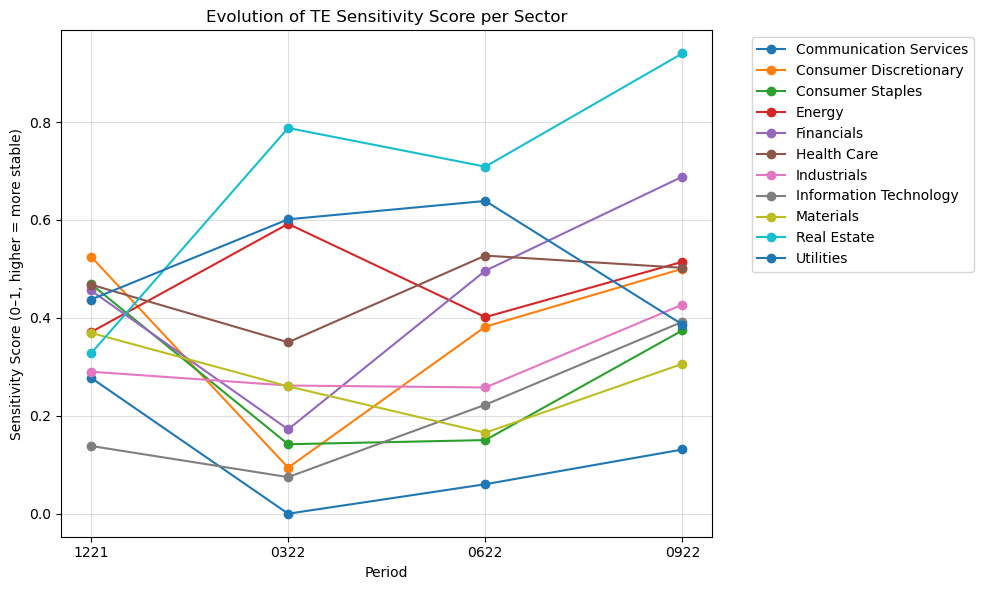

In [ ]:
averaged_room_for_maneuver_score_df = room_for_maneuver_score_df.groupby('Sector')['Room_for_Maneuver_Score'].mean()

averaged_room_for_maneuver_score_df = (
    (averaged_room_for_maneuver_score_df - averaged_room_for_maneuver_score_df.min()) /
    (averaged_room_for_maneuver_score_df.max() - averaged_room_for_maneuver_score_df.min())
)


averaged_flexibility_score_df = flexibility_score_df.groupby('Sector')['Flexibility_Score'].mean()

# --- Average Flexibility Score across time periods ---
averaged_flexibility_score_df = (
    flexibility_score_df
    .groupby('Sector', as_index=False)['Flexibility_Score']
    .mean()
    .rename(columns={'Flexibility_Score': 'Flexibility_Score_mean'})
)

# --- Normalize to 0–1 range for comparability ---
min_val = averaged_flexibility_score_df['Flexibility_Score_mean'].min()
max_val = averaged_flexibility_score_df['Flexibility_Score_mean'].max()

averaged_flexibility_score_df['Flexibility_Score'] = (
    (averaged_flexibility_score_df['Flexibility_Score_mean'] - min_val) /
    (max_val - min_val)
)



averaged_sensitivity_score_df = sensitivity_score_df.groupby('Sector')['Sensitivity_Score'].mean()

# --- Average Flexibility Score across time periods ---
averaged_sensitivity_score_df = (
    sensitivity_score_df
    .groupby('Sector', as_index=False)['Sensitivity_Score']
    .mean()
    .rename(columns={'Sensitivity_Score': 'Sensitivity_Score_mean'})
)

# --- Normalize to 0–1 range for comparability ---
min_val = averaged_sensitivity_score_df['Sensitivity_Score_mean'].min()
max_val = averaged_sensitivity_score_df['Sensitivity_Score_mean'].max()

averaged_sensitivity_score_df['Sensitivity_Score'] = (
    (averaged_sensitivity_score_df['Sensitivity_Score_mean'] - min_val) /
    (max_val - min_val)
)

averaged_robustness_score_df = robustness_score_df.groupby('Sector')['Robustness_Score'].mean()

In [ ]:
# --- Step 1: merge all averaged sector scores ---
combined_scores = (
    averaged_room_for_maneuver_score_df.reset_index()
    .merge(averaged_flexibility_score_df.reset_index()[['Sector', 'Flexibility_Score']], on="Sector", how="outer")
    .merge(averaged_sensitivity_score_df.reset_index(), on="Sector", how="outer")
    .merge(averaged_robustness_score_df.reset_index(), on="Sector", how="outer")
)


# --- Step 2: rename for readability ---
combined_scores = combined_scores.rename(columns={
    "Room_for_Maneuver_Score":"Room for Maneuver",
    "Flexibility_Score": "Flexibility",
    "Sensitivity_Score": "Sensitivity",
    "Robustness_Score": "Robustness"
})

# --- Step 3: handle missing values ---
combined_scores = combined_scores.fillna(0)

# --- Step 4: invert Sensitivity (bad → good) ---
# normalize first (0–1) if not already
def minmax_norm(x):
    x = (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0
    return x

combined_scores["Sensitivity_inverted"] = 1 - minmax_norm(combined_scores["Sensitivity"])

# --- Step 5: compute composite score ---
combined_scores["Composite_Score"] = (
    0.25 * combined_scores["Room for Maneuver"] +
    0.25 * combined_scores["Flexibility"] +
    0.25 * combined_scores["Sensitivity_inverted"] +
    0.25 * combined_scores["Robustness"]
)

# --- Step 6: save results ---
combined_scores.to_excel("results/combined_sector_scores.xlsx", index=False)



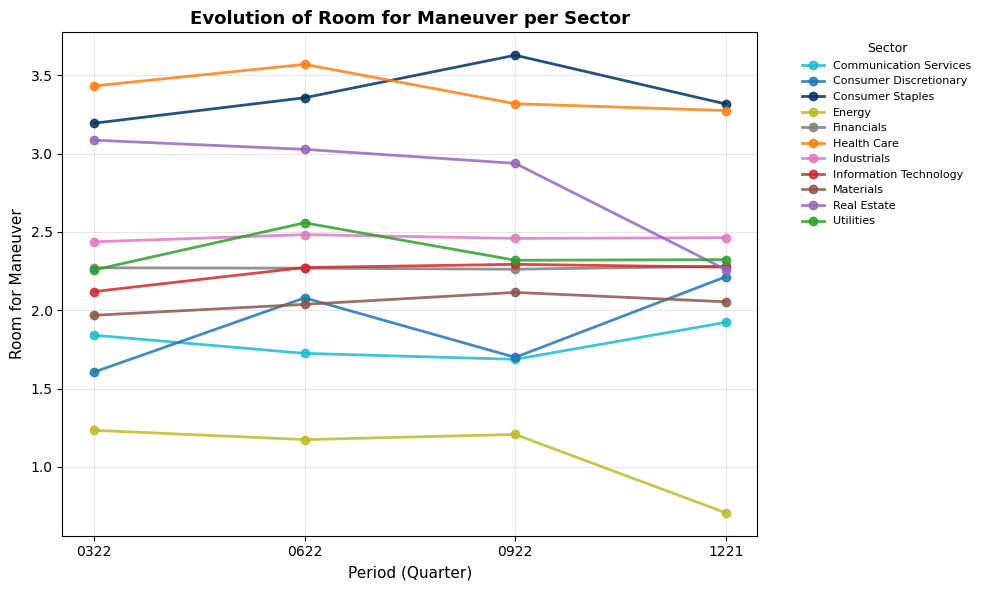

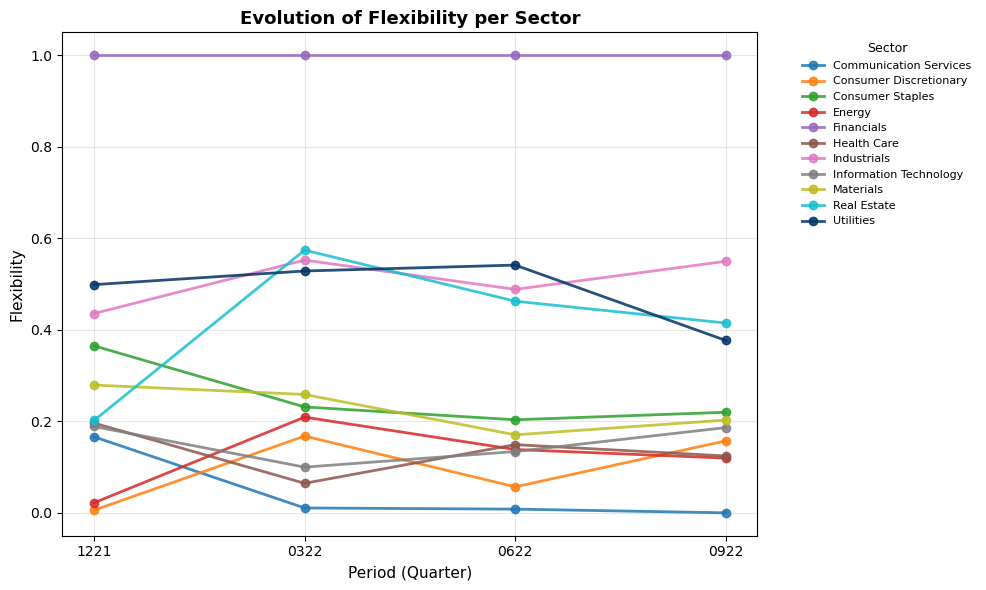

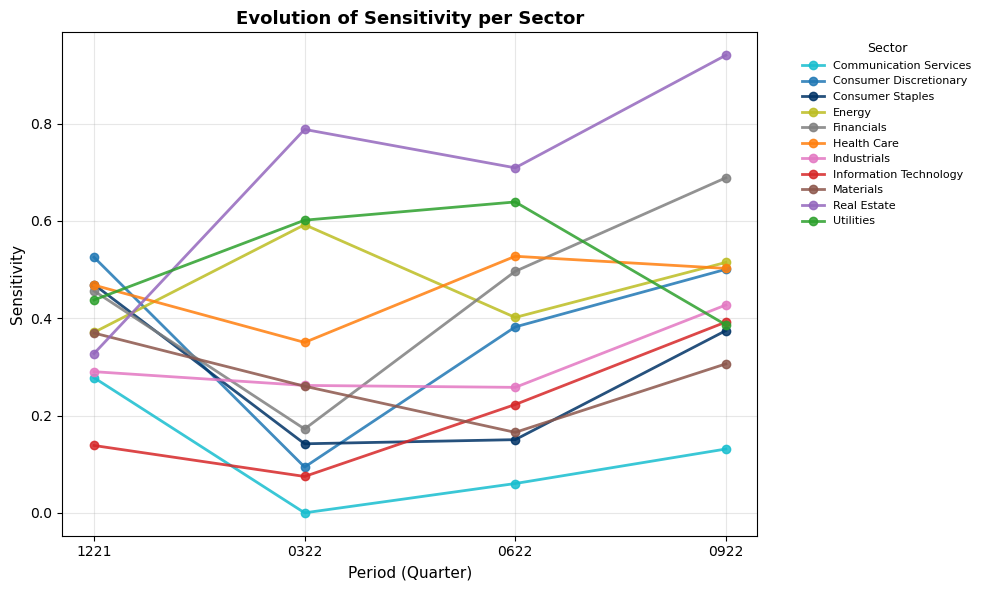

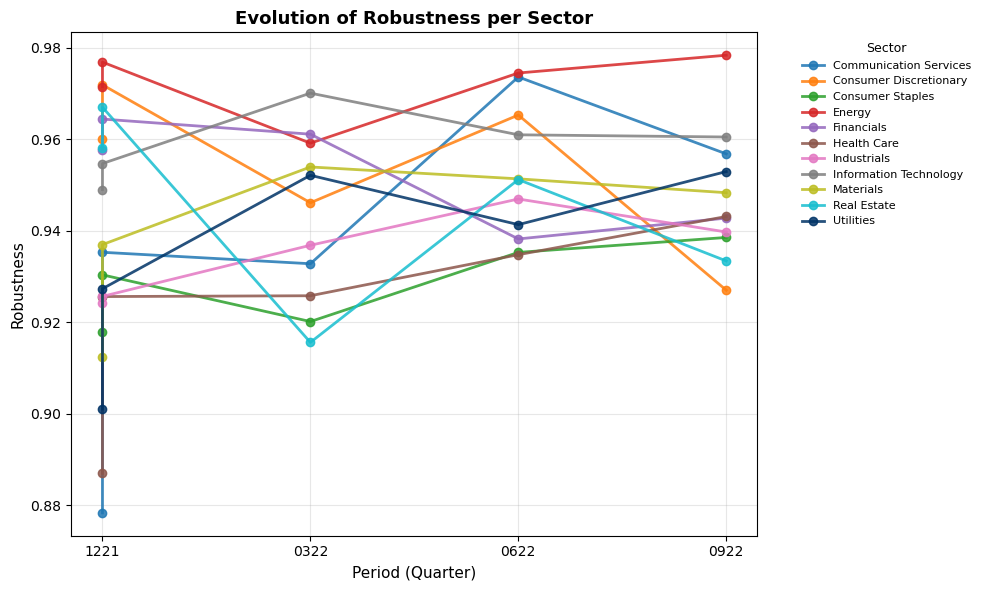

In [ ]:
for score, df in [('Room for Maneuver', room_for_maneuver_score_df), 
                  ('Flexibility', flexibility_score_df),
                  ('Sensitivity', sensitivity_score_df), 
                  ('Robustness', robustness_score_df)]:

    plot_sector_evolution(
        df,
        value_col=f"{score.replace(" ", "_")}_Score",
        title=f"Evolution of {score} per Sector",
        ylabel=f"{score}"
    )

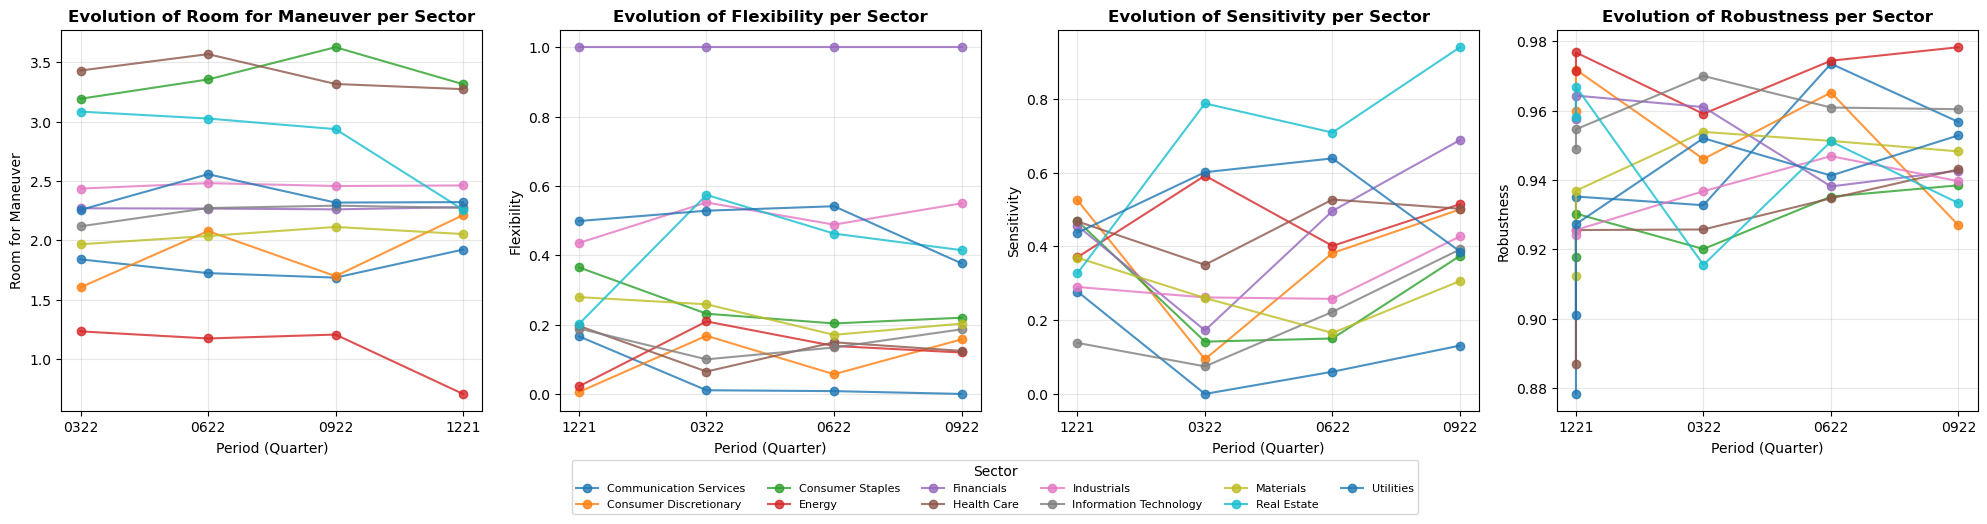

In [ ]:
def plot_sector_evolution(df, value_col, title, ylabel, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    for sector, grp in df.groupby("Sector"):
        ax.plot(grp["Period"], grp[value_col], marker="o", label=sector, alpha=0.8)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Period (Quarter)")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

    # ❌ Remove the legend here
    # ax.legend(fontsize=6, loc="best")

    if ax is None:
        plt.tight_layout()
        plt.show()


# --- Define your scores and dataframes ---
score_dfs = [
    ('Room for Maneuver', room_for_maneuver_score_df),
    ('Flexibility', flexibility_score_df),
    ('Sensitivity', sensitivity_score_df),
    ('Robustness', robustness_score_df),
]

# --- Create 1x4 grid of subplots ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

# --- Loop over subplots ---
for ax, (score, df) in zip(axes, score_dfs):
    plot_sector_evolution(
        df,
        value_col=f"{score.replace(' ', '_')}_Score",
        title=f"Evolution of {score} per Sector",
        ylabel=score,
        ax=ax
    )

# --- Create one shared legend ---
# Take handles & labels from the first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",          # 👈 place below all plots
    bbox_to_anchor=(0.5, -0.05), # move further below
    ncol=6,                      # number of columns in legend
    fontsize=8,
    title="Sector"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space for legend
plt.show()


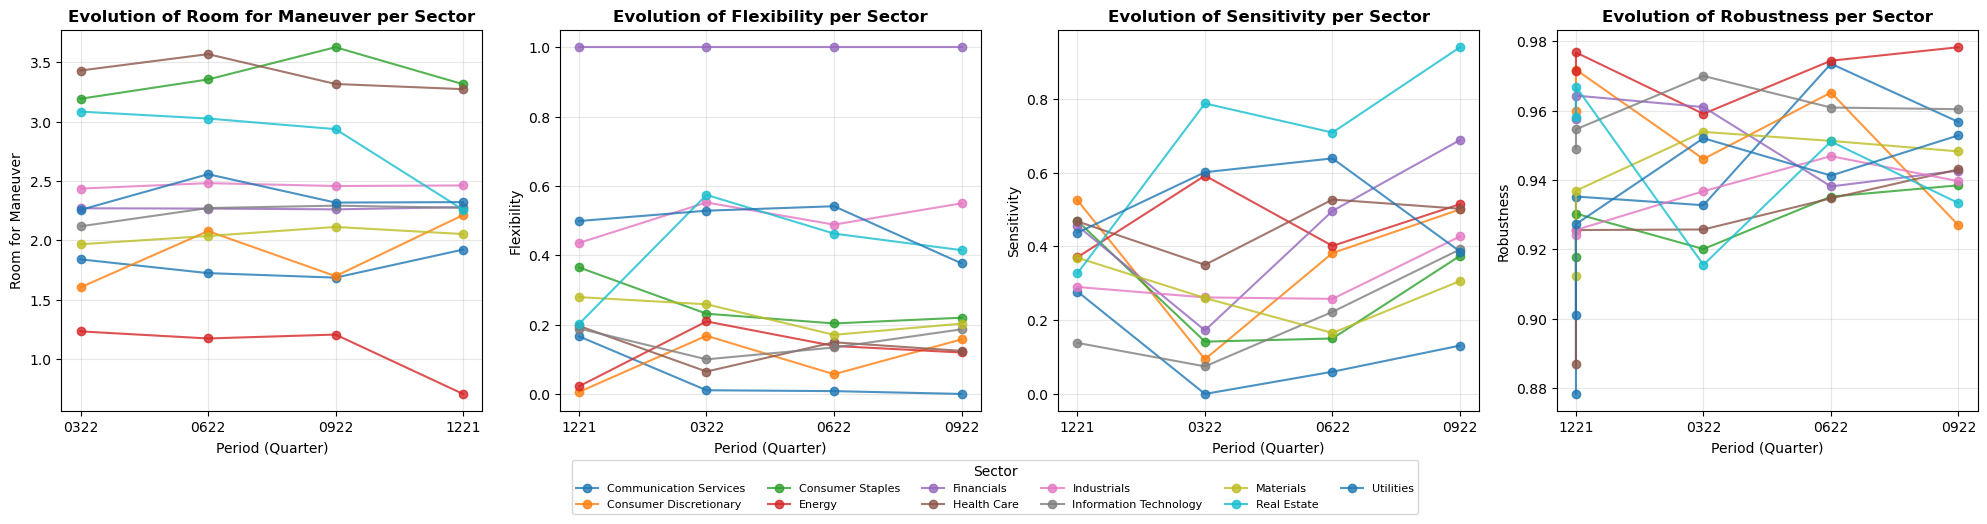

In [ ]:
def plot_sector_evolution(df, value_col, title, ylabel, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    for sector, grp in df.groupby("Sector"):
        ax.plot(grp["Period"], grp[value_col], marker="o", label=sector, alpha=0.8)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Period (Quarter)")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

    # ❌ Remove the legend here
    # ax.legend(fontsize=6, loc="best")

    if ax is None:
        plt.tight_layout()
        plt.show()


# --- Define your scores and dataframes ---
score_dfs = [
    ('Room for Maneuver', room_for_maneuver_score_df),
    ('Flexibility', flexibility_score_df),
    ('Sensitivity', sensitivity_score_df),
    ('Robustness', robustness_score_df),
]

# --- Create 1x4 grid of subplots ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

# --- Loop over subplots ---
for ax, (score, df) in zip(axes, score_dfs):
    plot_sector_evolution(
        df,
        value_col=f"{score.replace(' ', '_')}_Score",
        title=f"Evolution of {score} per Sector",
        ylabel=score,
        ax=ax
    )

# --- Create one shared legend ---
# Take handles & labels from the first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",          # 👈 place below all plots
    bbox_to_anchor=(0.5, -0.05), # move further below
    ncol=6,                      # number of columns in legend
    fontsize=8,
    title="Sector"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space for legend
plt.show()

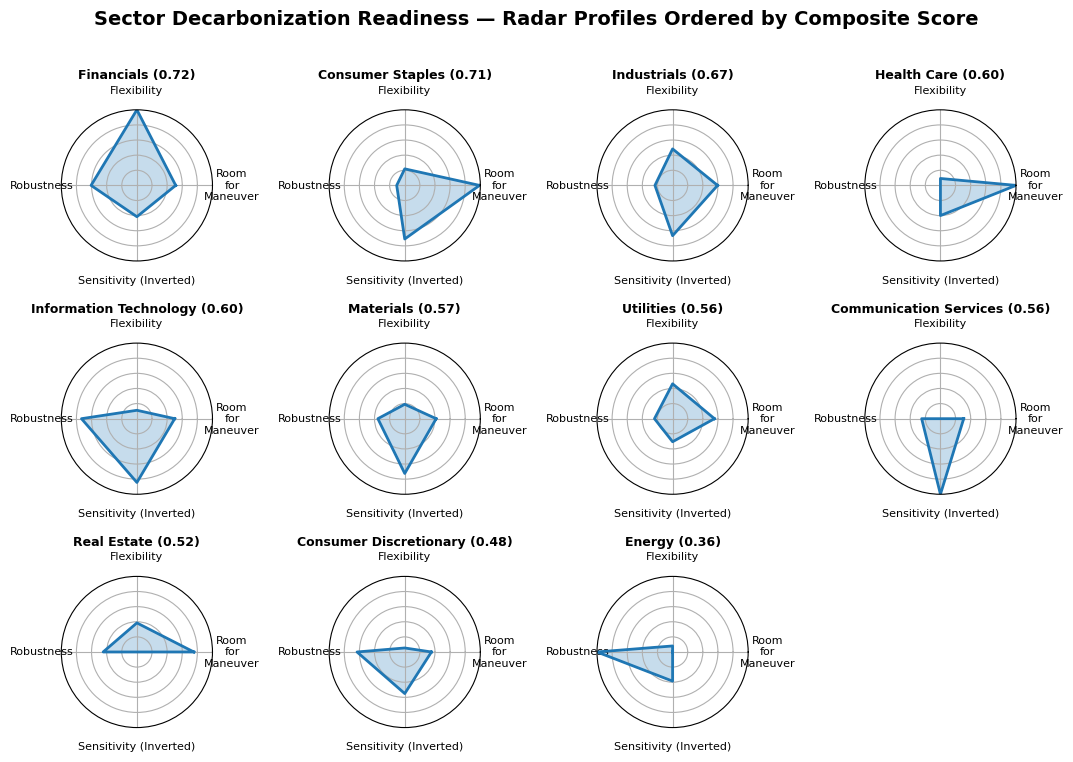

✅ Saved Decarbonization Readiness scores and ordered radar charts.


In [ ]:

# --- Load and normalize ---
combined_scores = pd.read_excel("results/combined_sector_scores.xlsx")

def minmax_norm(x):
    if x.max() == x.min():
        return np.ones_like(x)
    return (x - x.min()) / (x.max() - x.min())

cols_to_norm = ["Room for Maneuver", "Flexibility", "Robustness", "Sensitivity_inverted"]
norm_df = combined_scores.copy()
for c in cols_to_norm:
    norm_df[c] = minmax_norm(norm_df[c])

# --- Sort by Composite_Score ---
norm_df = norm_df.sort_values("Composite_Score", ascending=False).reset_index(drop=True)

# --- Radar setup ---
# Adjusted label formatting
labels = [
    "Room\nfor\nManeuver",     # three-line label
    "Flexibility",
    "Robustness",              # we'll rotate this slightly left
    "Sensitivity (Inverted)"
]
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the circle

# --- Auto subplot grid ---
n_sectors = len(norm_df)
ncols = 4
nrows = math.ceil(n_sectors / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    subplot_kw=dict(polar=True),
    figsize=(11, 2.5 *nrows)
)
axes = axes.flatten()

# --- Plot radar per sector in score order ---
for i, (_, row) in enumerate(norm_df.iterrows()):
    sector = row["Sector"]
    values = row[cols_to_norm].tolist() + [row[cols_to_norm[0]]]
    ax = axes[i]

    # Plot lines + fill
    ax.plot(angles, values, color="C0", linewidth=2)
    ax.fill(angles, values, color="C0", alpha=0.25)

    # Axis setup
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8, fontweight= 'light')
  
    #ax.tick_params(pad=14)  # default is usually around 5

    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticklabels([])
    ax.set_ylim(0, 1
)

    # Title = sector name + composite score
    ax.set_title(
        f"{sector} ({row['Composite_Score']:.2f})",
        size=9,
        fontweight="bold",
        y=1.15
    )


# --- Remove empty plots if grid > #sectors ---
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Sector Decarbonization Readiness — Radar Profiles Ordered by Composite Score",
    fontsize=14,
    fontweight="bold",
    y=1.01
)
plt.tight_layout(h_pad=1, w_pad = 0.1)
# --- Save figure ---
fig.savefig(
    "results/decarbonization_radar_profiles_new.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# --- Save final scored table ---
norm_df.to_excel("results/decarbonization_readiness_scores.xlsx", index=False)
print("✅ Saved Decarbonization Readiness scores and ordered radar charts.")